In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/Walmart.csv')
print("Dataset loaded successfully")

Dataset loaded successfully


In [ ]:
#check first 5 rows

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df.shape

#6345 rows (store and weekly entiries) and 9 columns (features and target)

(6435, 8)

In [ ]:
df.columns

#target variable: Weekly sale
#time variable = Date

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [ ]:
df.dtypes

#check datatype as date should be date-time and sale would be numeric

#covert object(text) the datatype of Date to (DAte time)

,0
Store,int64
Date,object
Weekly_Sales,float64
Holiday_Flag,int64
Temperature,float64
Fuel_Price,float64
CPI,float64
Unemployment,float64


In [ ]:
#check for missing value:
df.isnull().sum()


#shows no missing val

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [ ]:
df.describe()

#check mean,std dev, max, min later will help in data cleaning if outlier etc is there.

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [ ]:
#Convert datatype of Date from obj to date time.

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("Date column converted to datetime successfully")

#why we did this:

#we cant extract year/month/week from text(datatype) while the time series model require datetime

Date column converted to datetime successfully


In [ ]:
#verify

df.dtypes

,0
Store,int64
Date,datetime64[ns]
Weekly_Sales,float64
Holiday_Flag,int64
Temperature,float64
Fuel_Price,float64
CPI,float64
Unemployment,float64


In [ ]:
df['Year'] = df['Date'].dt.year

df[['Date', 'Year']].head()

#extracting year from each column and make a new column for year so that we can see the impact of year on sales.

,Date,Year
0,2010-02-05,2010
1,2010-02-12,2010
2,2010-02-19,2010
3,2010-02-26,2010
4,2010-03-05,2010


In [ ]:
df['Month'] = df['Date'].dt.month

df[['Date', 'Month']].head()

#same way month are extracted to check if any season has more influence on sales like nov, dec.

,Date,Month
0,2010-02-05,2
1,2010-02-12,2
2,2010-02-19,2
3,2010-02-26,2
4,2010-03-05,3


In [ ]:
df['Week'] = df['Date'].dt.isocalendar().week

df[['Date', 'Week']].head()

#same way weekly as well

,Date,Week
0,2010-02-05,5
1,2010-02-12,6
2,2010-02-19,7
3,2010-02-26,8
4,2010-03-05,9


In [ ]:
df['DayOfWeek'] = df['Date'].dt.day_name()

df[['Date', 'DayOfWeek']].head()

#by day as well to understand rather deeply the impact

,Date,DayOfWeek
0,2010-02-05,Friday
1,2010-02-12,Friday
2,2010-02-19,Friday
3,2010-02-26,Friday
4,2010-03-05,Friday


In [ ]:
df = df.sort_values('Date')

print("Dataset sorted by date")

#sorted the date as the past values will come first then future so that model learns properly

Dataset sorted by date


In [ ]:
df.set_index('Date', inplace=True)

df.head()

#set the date as main index value which is also telling the the dataset is time based.

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,DayOfWeek
Date,,,,,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,Friday
2010-02-05,4,2135143.87,0,43.76,2.598,126.442065,8.623,2010,2,5,Friday
2010-02-05,31,1469252.05,0,39.05,2.572,210.752605,8.324,2010,2,5,Friday
2010-02-05,16,477409.30,0,19.79,2.580,189.381697,7.039,2010,2,5,Friday
2010-02-05,11,1528008.64,0,46.04,2.572,214.424881,7.368,2010,2,5,Friday


In [ ]:
df.info()

#final check to see all updated columns and date.

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6435 entries, 2010-02-05 to 2012-10-26
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Weekly_Sales  6435 non-null   float64
 2   Holiday_Flag  6435 non-null   int64  
 3   Temperature   6435 non-null   float64
 4   Fuel_Price    6435 non-null   float64
 5   CPI           6435 non-null   float64
 6   Unemployment  6435 non-null   float64
 7   Year          6435 non-null   int32  
 8   Month         6435 non-null   int32  
 9   Week          6435 non-null   UInt32 
 10  DayOfWeek     6435 non-null   object 
dtypes: UInt32(1), float64(5), int32(2), int64(2), object(1)
memory usage: 534.2+ KB


In [ ]:
#Data cleaning:

#check for negative values

(df['Weekly_Sales'] < 0).sum()


np.int64(0)

In [ ]:
#duplicate rows:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Weekly_Sales'].describe()


#check outlier by seeing min max mean but its look like stable.

,Weekly_Sales
count,6.435000e+03
mean,1.046965e+06
std,5.643666e+05
min,2.099862e+05
25%,5.533501e+05
50%,9.607460e+05
75%,1.420159e+06
max,3.818686e+06


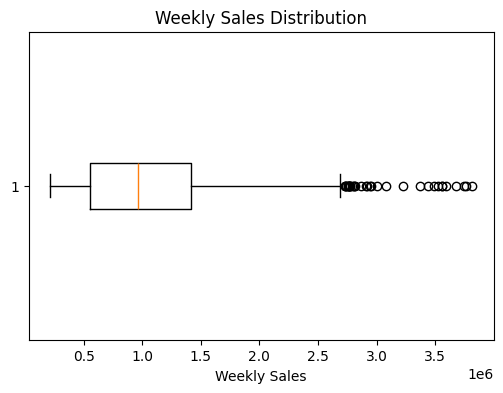

In [ ]:
#boxplot to detect:

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df['Weekly_Sales'], vert=False)
plt.title('Weekly Sales Distribution')
plt.xlabel('Weekly Sales')
plt.show()


#they are not outlier but the sales happen on christmas, Eid etc. we wont remove them as they are critical.

In [ ]:
store_df = df[df['Store'] == 1]

store_df.head()


#taking only one store to work with ARIMA model as it works on one clean time series will do for other later.
#multiple stores will give multiple patterns.

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,DayOfWeek
Date,,,,,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,Friday
2010-02-12,1,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,Friday
2010-02-19,1,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,Friday
2010-02-26,1,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,Friday
2010-03-05,1,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,Friday


In [ ]:
store_df.index.min(), store_df.index.max(), store_df.shape


#seeing the total record of store 1.

(Timestamp('2010-02-05 00:00:00'), Timestamp('2012-10-26 00:00:00'), (143, 11))

In [ ]:
ts = store_df['Weekly_Sales']

ts.head()

#making the sales as the target variable for the model.

#Date to weeklysales

,Weekly_Sales
Date,
2010-02-05,1643690.90
2010-02-12,1641957.44
2010-02-19,1611968.17
2010-02-26,1409727.59
2010-03-05,1554806.68


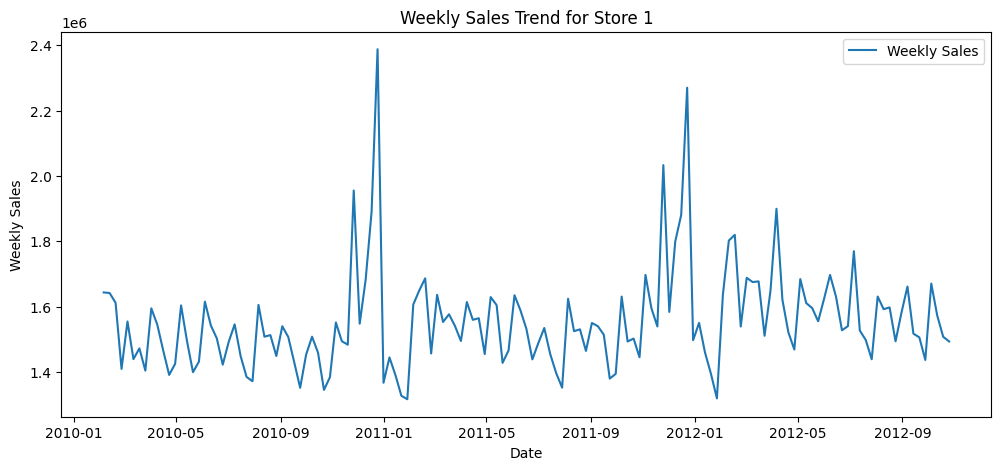

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(ts, label='Weekly Sales')
plt.title('Weekly Sales Trend for Store 1')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

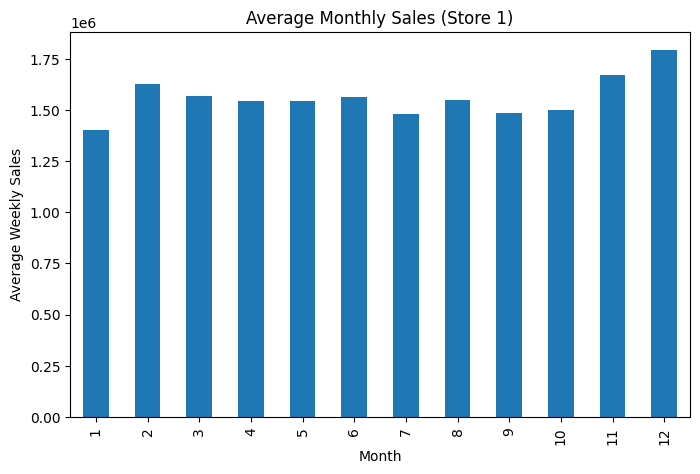

In [ ]:
monthly_avg = store_df.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(8,5))
monthly_avg.plot(kind='bar')
plt.title('Average Monthly Sales (Store 1)')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')
plt.show()

#Sales are high in month of November and December.

In [ ]:
holiday_sales = store_df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

holiday_sales

,Weekly_Sales
Holiday_Flag,
0,1.546957e+06
1,1.665748e+06


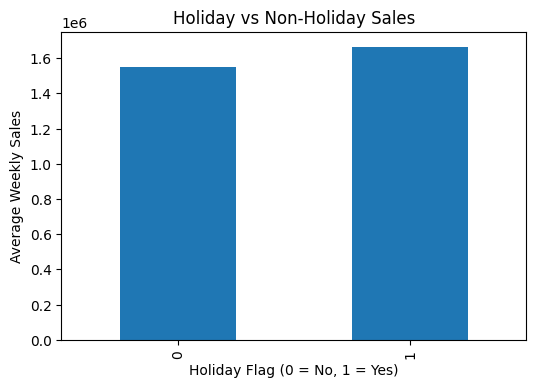

In [ ]:
plt.figure(figsize=(6,4))
holiday_sales.plot(kind='bar')
plt.title('Holiday vs Non-Holiday Sales')
plt.xlabel('Holiday Flag (0 = No, 1 = Yes)')
plt.ylabel('Average Weekly Sales')
plt.show()

#Sales are higher on holidays as compare to working days.

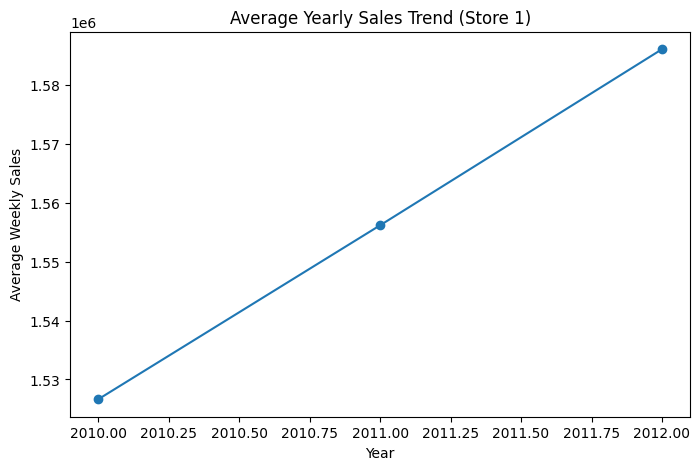

In [ ]:
yearly_avg = store_df.groupby('Year')['Weekly_Sales'].mean()

plt.figure(figsize=(8,5))
yearly_avg.plot(marker='o')
plt.title('Average Yearly Sales Trend (Store 1)')
plt.xlabel('Year')
plt.ylabel('Average Weekly Sales')
plt.show()

#Shows the sales are increasing each year

In [ ]:
#Justification:


#Visual analysis of weekly sales tells seasonal patterns with  spikes during holiday periods.
#Monthly analysis showed higher sales during November and December indicating peak demand
#Holiday weeks consistently have more sales than non-holiday weeks so need to increased inventory during these periods.

In [ ]:
#MODEL = ARIMA

#check the data is stationary as the ARIMA works on stationary data.

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(ts)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])


# P > 0.05 so the data is statiinary.

ADF Statistic: -5.102186145192288
p-value: 1.3877788330759434e-05


In [ ]:
#Senario: if data wasnt stationary:


#Apply 1st order deferencing:

ts_diff = ts.diff().dropna()

print("Differencing applied")


#it subtracts this week sales with last week sales and now we are modelling the changes in sales which makes data stationary

# Week   sales difference
#  2	    110	    10
#  3	    120	    10


#here the difference is 10 variation and mean is constant that stationary.


Differencing applied


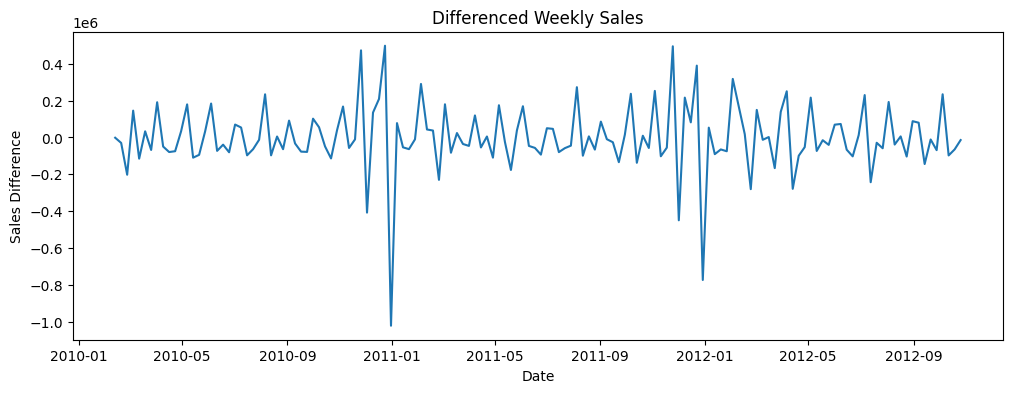

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(ts_diff)
plt.title('Differenced Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Sales Difference')
plt.show()

#Positive value = sales increased from last week

#Negative value = sales decreased from last week


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())


#ARIMA (1,1,1) =

#d = 1 (modeled changes in sales to make patterns smoother)

#p = 1 (Sales depend on last week’s sales)

#q = 1 (The model corrects itself using last week’s error)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  143
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1905.518
Date:                Sat, 28 Feb 2026   AIC                           3817.037
Time:                        19:31:20   BIC                           3825.904
Sample:                    02-05-2010   HQIC                          3820.640
                         - 10-26-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3937      0.057      6.865      0.000       0.281       0.506
ma.L1         -0.9367      0.032    -29.470      0.000      -0.999      -0.874
sigma2      2.445e+10   3.44e-14    7.1e+23      0.0

In [ ]:
forecast = model_fit.forecast(steps=8)

forecast

,predicted_mean
2012-11-02,1.538713e+06
2012-11-09,1.556450e+06
2012-11-16,1.563433e+06
2012-11-23,1.566182e+06
2012-11-30,1.567265e+06
2012-12-07,1.567691e+06
2012-12-14,1.567859e+06
2012-12-21,1.567925e+06


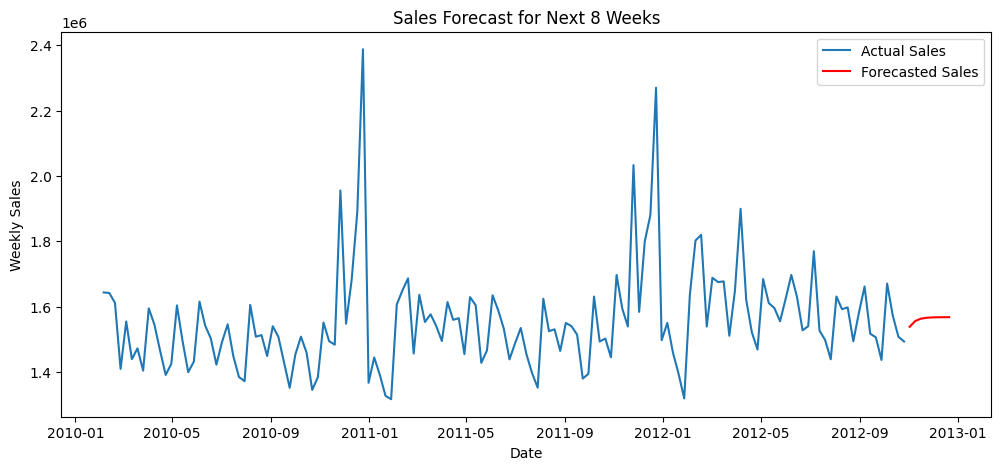

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(ts, label='Actual Sales')
plt.plot(forecast, label='Forecasted Sales', color='red')
plt.title('Sales Forecast for Next 8 Weeks')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()


#Blue = previous Sales.
#Red = Predicted next 4 weeks sales (expected to be higher from last weeks)

In [ ]:
#Evalulation:

#As to evaluate we have only historical data so we will divide it into 2 (Training/ Test)

train = ts[:-8]
test = ts[-8:]

print("Training size:", len(train))
print("Test size:", len(test))


#train is last 8 week data, test is recent last 2 weeks data.


predictions = model_fit.forecast(steps=8)

predictions

Training size: 135
Test size: 8


,predicted_mean
2012-09-07,1.587252e+06
2012-09-14,1.589317e+06
2012-09-21,1.590141e+06
2012-09-28,1.590471e+06
2012-10-05,1.590602e+06
2012-10-12,1.590655e+06
2012-10-19,1.590676e+06
2012-10-26,1.590684e+06


In [ ]:
comparison_df = pd.DataFrame({
    'Actual Sales': test,
    'Predicted Sales': predictions
})

comparison_df

#now we have actual and predicted sale.

,Actual Sales,Predicted Sales
2012-09-07,1661767.33,1.587252e+06
2012-09-14,1517428.87,1.589317e+06
2012-09-21,1506126.06,1.590141e+06
2012-09-28,1437059.26,1.590471e+06
2012-10-05,1670785.97,1.590602e+06
2012-10-12,1573072.81,1.590655e+06
2012-10-19,1508068.77,1.590676e+06
2012-10-26,1493659.74,1.590684e+06


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

#On average, prediction is off by about 82,653 units of sales per week

#conclusion:

#RMSE shows that how big the model’s larger mistakes are.
#Here RMSE is close to MA. so it shows that the model does not make extreme errors.

MAE: 82653.32002720592
RMSE: 89645.24778568273


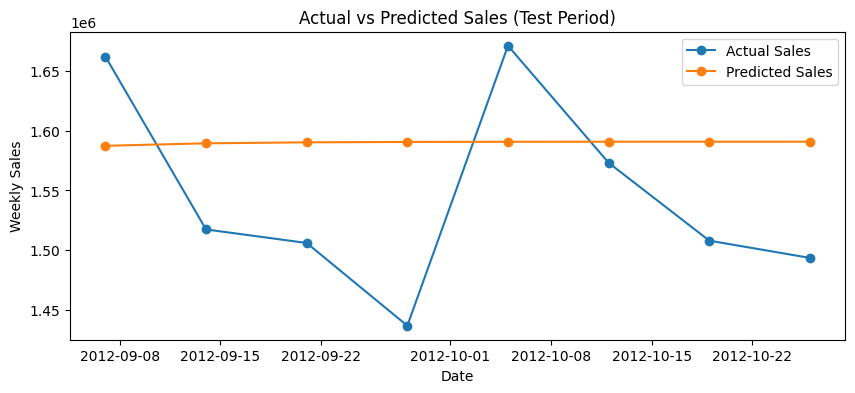

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(test.index, test, label='Actual Sales', marker='o')
plt.plot(predictions.index, predictions, label='Predicted Sales', marker='o')
plt.title('Actual vs Predicted Sales (Test Period)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

In [ ]:
#Conclusion:

#Walmart experiences peak demand during holiday periods and late-year months (November and December).
#Inventory levels should be increased during high-demand months and holiday weeks.
#The sales data shows clear seasonality with peaks during specific months (Nov,Dec) and holidays each year.
#The forecasting model helps management plan inventory in advance to avoid any inconvinience.

In [ ]:
#FINAL BUSINESS CONCLUSION:

# Based on the forecasting results, sales are expected to increase during November and December.
# Inventory should be increased during these periods to avoid stockouts.
# Off-season demand drops during early-year months such as February and March, suggesting optimized storage management
